In [357]:
from escripts import edata
from escripts import eMCMC
from escripts import eplots
from matplotlib.gridspec import GridSpec
import math
from matplotlib import ticker
from matplotlib.transforms import Bbox
from collections import OrderedDict
import zeus21
from matplotlib.legend_handler import HandlerTuple
from collections import OrderedDict

In [358]:
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_low_z.txt', 
              '/Users/eb35267/Desktop/code/home/data/Donnan24_limit_z.txt']
data_labels = ['Bouwens+21', 'Donnan+24']
sorted_data = edata.get_sorted(file_names, data_labels)

In [359]:
params = eMCMC.build_param_data({'beta': {'fit': False, 'value': -1.49}, 'dbetadz': {'fit': False, 'value': 0.22}})
my_UVLF = eMCMC.UVLF(sorted_data, params)

In [360]:
fiducial = [0.531, -0.001, 11.712, -0.057, -1.338, -0.113, 0.486, 0.229,
-0.152, 0.678]
redshift_dependent = [0.49, -0.019, 11.757, -0.04, -1.344, -0.117, 0.527,
0.236, 0, 0.668]
mass_dependent = [0.818, -0.032, 11.995, 0.05, -1.373, -0.138, 0.992,
0, -0.796, 0.677]
non_evolving = [0.388, -0.075, 12.051, 0.083, -1.388, -0.127, 0.754, 0, 
0, 0.3]
piecewise = [0.51, -0.02, 11.74, -0.04, -1.33, -0.12, [0.64, 0.67, 0.65, 0.69, 0.6, 0.69, 1.05, 1.46, 1.56], 0, 0, 0.3]

# Piecewise figure

In [116]:
lowers = np.array([0.04, 0.03, 0.05, 0.07, 0.1, 0.12, 0.1, 0.08, 0.08])
uppers = np.array([0.04, 0.03, 0.03, 0.04, 0.06, 0.07, 0.05, 0.05, 0.05])

yerr = np.vstack((lowers, uppers))

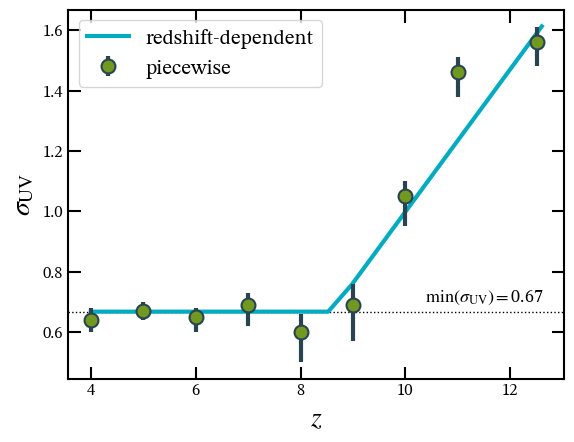

In [124]:
fig, ax = plt.subplots()
zs = np.linspace(4, 12.6, 20)
sig_lin = [my_UVLF.time_evolution(redshift_dependent, z)[-1][-1] for z in zs]
ax.plot(zs, sig_lin, color = eplots.turquoise, label = 'redshift-dependent')
ax.errorbar(my_UVLF.zs, piecewise[-4], fmt = 'o', color = eplots.green, yerr = yerr, markersize = 10, ecolor = eplots.navy, 
            label = f'piecewise', markeredgecolor = eplots.navy, markeredgewidth = 1.5)

ax.axhline(redshift_dependent[-1], zorder = 0, ls = 'dotted', color = 'black', lw = 1)
ax.text(11.5, 0.7, r'$\min(\sigma_{\rm{UV}}) = $' + f'{round(redshift_dependent[-1], 2)}', size = 13, ha = 'center')

ax.set_ylabel(r'$\sigma_{\rm{UV}}$')
ax.set_xlabel(r'$z$')
ax.legend()

In [125]:
fig.savefig('/Users/eb35267/Desktop/figures/Qual_26/Final/piecewise.png', dpi = 300)

In [217]:
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_low_z.txt',
              '/Users/eb35267/Desktop/code/home/data/Donnan24_limit_z.txt',
             '/Users/eb35267/Desktop/code/home/data/Donnan24_high_z.txt',
             '/Users/eb35267/Desktop/code/home/data/Kokorev+25.txt',
             '/Users/eb35267/Desktop/code/home/data/Weibel+25_upper_limits.txt']
data_labels = ['Bouwens+21', 'Donnan+24', r'Donnan+24 ultra high-$z$', 'Kokorev+25', 'Weibel+25']
include = [True, True, False, False, False]
sorted_data = edata.get_sorted(file_names, data_labels, include_in_likelihood=include)


In [361]:
my_UVLF = eMCMC.UVLF(sorted_data, params)

In [367]:
def evolving_UVLF_fit(my_UVLF, backend_file = None, z_plot = None, z_errs = None, plot_from_chain = True, nsamples = 100, 
                      
                      comparison_fits = [], comparison_labels = [], 
                      ncols = 3, burn_in = None, show_chi2 = True, data_fmt = None, fit_colors = None):
    """
    Plot the UVLF at different redshifts
    Inputs:
        my_UVLF: eMCMC UVLF object
        backend_file [str]: .h5 file containing previously saved chain
        z_plot [list of floats]: redshifts to plot, or None if you want to plot all the redshifts for which there exists data
        z_errs [list of floats]: the uncertainty in redshift, or None if you want to use the uncertainty that corresponds to the data.
                                If you provide redshifts to plot but no redshift error, it will default to 0.5.
        plot_from_chain [bool]: whether or not to plot the best fit and samples from the chain stored in my_UVLF. If False, only comparison_fits
                             parameter values will be plotted (so you can quickly check different fits this way).
        nsamples [int]: number of samples from the MCMC chain you want to appear in addition to the best fit
        comparison_fits [list of lists]: lists of parameter values that will be used to create comparison UVLFs
        comparison_labels [list of strs]: labels that correspond to the parameter values in comparison_fits, for the legend
        ncols [int]: number of columns to plot
        burn_in [int]: number of samples to discard as burnin. If None, the default value will be used (see UVLF.get_fit())
        show_chi2 [bool]: whether or not to show the chi squared of the fit(s). Does not apply if plot_from_chain is True
        data_fmt [list]: list of scatter plot styles
        fit_colors [list]: list of colors for the different models
    Outputs:
        Figure showing the UVLF at different redshfits
    """

    data_z = [dat[0] for dat in my_UVLF.data] # Get the redshifts that correspond to the input data

    if z_plot is None:
        z_plot = data_z
        z_errs = [dat[1] for dat in my_UVLF.data]
        dat = my_UVLF.data
    else:
        if z_errs is None:
            z_errs = np.full_like(z_plot, 0.5, dtype = float)
        if type(z_plot) == list:
            z_plot = np.array(z_plot)
        if type(z_errs) == list:
            z_errs = np.array(z_errs)

        idxs = np.concatenate([np.where(np.abs(data_z - z) < z_err)[0] for z, z_err in zip(z_plot, z_errs)])
        dat = [my_UVLF.data[i] for i in idxs]
    

    if len(comparison_fits) > 0:
        assert len(comparison_labels) > 0, 'If specifying comparison fits you must also give their labels'

    # Figure out how many subplots to make
    nz = len(z_plot)
    fig = plt.figure()
    gs = GridSpec(math.ceil((nz+1)/ncols), ncols, figure=fig)
    plt.subplots_adjust(wspace = 0, hspace = 0.3)
    
   
    # Get samples & best fit
    if plot_from_chain:
        samples, best_fit, _, _= my_UVLF.get_fit(backend_file = backend_file, exclude_unfit = True, burn_in = burn_in)
        print(best_fit)
    
    chi2_comparison = [-2*my_UVLF.log_like(fit, dat) for fit in comparison_fits]

    # Set the same y limits for all the plots
    # Flatten all ydat values from sorted_data
    all_ydat = np.concatenate([np.concatenate([ds[3] for ds in z_separated])  # ds[3] is ydat
                               for z_separated in my_UVLF.sorted_data])
    

    ylo, yhi = np.log10(all_ydat.min()) - 1, np.log10(all_ydat.max()+0.1)


    # Flatten all xdat and xerr across all redshifts and datasets
    MUVcenters, MUVwidths = my_UVLF.get_all_MUV_bins()

    # Plotting details
    if data_fmt is None:
        data_fmt = ['o', 'v', 'v', 's', 'D', '^', 'P']
    if fit_colors is None:
        fit_colors = [turquoise, yellow, orange, green]

    axs = []
    for i, (z, z_err) in enumerate(zip(z_plot, z_errs)): 

        ax = fig.add_subplot(gs[math.floor(i/ncols), i%ncols])
        axs.append(ax)

        if plot_from_chain:
            # Choose random samples from the MCMC chain
            inds = np.random.randint(len(samples), size=nsamples) # Choose nsamples from the chain

            # Plot each sample from the chain
            for ind in inds: 
                sample = samples[ind]
                ax.plot(MUVcenters, np.log10(my_UVLF.UVLF_wrapper(z,z_err, MUVcenters, MUVwidths,sample)), alpha=6/max(nsamples, 6), 
                           color = red, linestyle = '-', zorder = 0)
    
            # Plot best fit
            chi2 = -2* my_UVLF.log_like(best_fit, alt_data = dat)

            ax.plot(MUVcenters, np.log10(my_UVLF.UVLF_wrapper(z, z_err, MUVcenters, MUVwidths, best_fit)), color = red, linestyle = '-', 
                                           zorder = 0, label = fr'best fit, $\chi^2 = {chi2:.0f}$', lw = 5)
            
            ax.plot([0], [0], color = red, alpha = 0.1, label = f'{nsamples} samples from chain', linestyle = '-', lw = 5) # Create the label for the samples

        # Plot comparison fits
        for fit, chi2_fit, label, color, ls, lw in zip(comparison_fits, chi2_comparison, comparison_labels, fit_colors, 
                                        ['solid', 'dashdot', 'dotted', 'dotted', 'dashed'], [7, 3, 2.5, 2.5, 2.5]):
            if show_chi2:
                fit_label = fr'{label}, $\chi^2 = {chi2_fit:.0f}$'
                print(fit_label)
            else:
                fit_label = f'{label}'
            ax.plot(MUVcenters, np.log10(my_UVLF.UVLF_wrapper(z,z_err,MUVcenters, MUVwidths,fit)), color = color, 
                       label = fit_label, linestyle = ls, zorder = 1, linewidth = lw)
        
        # Plot data
        all_dat_z = [dat[0][0] for dat in my_UVLF.sorted_data]
        idx = np.where(np.abs(all_dat_z - z) <= z_err)[0]
        if len(idx) > 0:
            for zbin in [my_UVLF.sorted_data[idx_i] for idx_i in idx]:
            #zbin = my_UVLF.sorted_data[idx[0]]

                for dat_z, fmt in zip(zbin, data_fmt): 
                    xdat, ydat, yerr_upper, yerr_lower, xerr, upper_lim_bool = dat_z[2], dat_z[3], dat_z[4], dat_z[5], dat_z[6], dat_z[7].astype('bool')
                    ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-', colors = eplots.navy, linewidth =5)
                    
                    # Show upper limits with a unique plotting style
                    for x, y in zip(xdat[upper_lim_bool], ydat[upper_lim_bool]):
                        ax.vlines(x, np.log10(y)-0.75, np.log10(y), ls = '-', colors = eplots.navy, linewidth = 5, alpha = 0.5)
                        ax.scatter(x-0.015, np.log10(y)-0.75, marker = 'v', c = eplots.navy, s = 65) # down arrow

                    if dat_z[-1]: # This indicates whether the data was used in the MCMC likelihood or not
                        for x, y in zip(xdat[upper_lim_bool], ydat[upper_lim_bool]):
                            ax.scatter(x, np.log10(y), marker = fmt, label = dat_z[8], facecolors = 'white', edgecolors = eplots.navy, s = 125, 
                                zorder = 4, linewidth = 3)
                        for x, y in zip(xdat[np.invert(upper_lim_bool)], ydat[np.invert(upper_lim_bool)]): # Account for the fact that upper limits cannot currently be included in the MCMC likelihood
                            ax.scatter(x, np.log10(y), marker = fmt, label = dat_z[8], c = eplots.navy, s = 125)
                    else: 
                        ax.scatter(xdat, np.log10(ydat), marker = fmt, label = dat_z[8], facecolors = 'white', edgecolors = eplots.navy, s = 125, 
                                zorder = 4, linewidth = 3)

        ax.invert_xaxis() 
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True)) # Make it so that only integers can be used in the  
                                                                                    # axis labels                                                                            
        ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True)) # Make it so that only integers can be used in the  
                                                                                    # axis labels
        ax.set_title(fr'${round(z-z_err, 1)} \lesssim z \lesssim {round(z+z_err, 1)}$', fontsize = 20, pad = 8)


    # Text & labels
    ylabel = r'$\log_{10}(\phi_{\rm{UV}}$ [$\rm{mag}^{-1} \rm{Mpc}^{-3}$])'
    xlabel = r'$M_{\rm{UV}}$ [mag]'

    # Formatting, labels
    multicol(gs, axs, xlabel, ylabel, xlims = (np.max(MUVcenters)+0.25, np.min(MUVcenters)-0.25), ylims = (ylo, yhi), include_legend = True)
    
    return fig


def multicol(gs, axs, xlabel = '', ylabel = '', xlims = None, ylims = None, include_legend = False):
    """
    Helper function for formatting multi-column plots.
    
    :param gs: matplotlib GridSpec object
    :param axs: list of axes in the figure
    :param xlabel: x axis label text
    :param ylabel: y axis label text
    :param xlims: tuple with the upper and lower x limit to be imposed for each subplot
    :param ylims: tuple with the upper and lower y limit to be imposed for each subplot. 
    :param include_legend: boolean-- whether or not to include a legend. Relies on there being labels in the axes within axs
    """
    
    N = len(axs)
    if include_legend:
        N_inc_leg = N+1
    else:
        N_inc_leg = N

    # Sizing & spacing
    fig = gs.figure
    fig.set_size_inches(4*gs.ncols, 4*math.ceil(N_inc_leg/gs.ncols))

    # Formatting axis ticks
    for i, ax in enumerate(axs): 
        if xlims is not None:
            ax.set_xlim(*xlims)
        if ylims is not None:
            ax.set_ylim(*ylims)                                                                       
            if i%gs.ncols != 0:
                ax.axes.yaxis.set_ticklabels([]) # Only include y axis tick labels on the furthest left side if all axes will have the same y limits

    # Text & labels
    bbox = Bbox.union([ax.get_position() for ax in axs]) # Define the positions of all the axes
    xcenter = bbox.x0 + bbox.width / 2
    ycenter = bbox.y0 + bbox.height / 2
    fig.text(xcenter, bbox.y0-0.03, xlabel, ha='center', va='top', fontsize = 20)
    fig.text(bbox.x0 - 0.1 + (gs.ncols/75), ycenter, ylabel, ha='center', va='center', rotation='vertical', fontsize = 20)

    # Create legend & place it outside the axes
    if include_legend:
        legend = OrderedDict() # Avoids duplicates & ensures that the legend is in order of what people will see first
        for ax in axs:
            for h, l in zip(*ax.get_legend_handles_labels()):
                legend.setdefault(l, h)
        handles, labels = list(legend.values()), list(legend.keys())

        # Placement
        fig_ax = fig.add_subplot(gs[math.floor((N)/gs.ncols), (N)%gs.ncols])
        fig_ax.axis("off")  
        # handles = [handles[0], handles[1], handles[2], handles[3], handles[4], handles[-1], handles[6], handles[7]]
        # labels = [r'fiducial, $\chi^2 = 48$', r'redshift dependent, $\chi^2 = 48$', r'mass dependent, $\chi^2 = 57$', r'non-evolving, $\chi^2 = 79$', 'Bouwens+21', 'Donnan+24', 'Kokorev+25', 'Weibel+25']

        # fig_ax.legend(handles, labels, bbox_to_anchor=(1.01, 1.047), fontsize = 14)

/Users/eb35267/Desktop/code/repos/Zeus21/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_64933/1053327681.py:124: RuntimeWarning: divide by zero encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-', colors = eplots.navy, linewidth =5)
/var/folders/mm/m_9lg4t966qdjwf1r__0773r0000gq/T/ipykernel_64933/1053327681.py:124: RuntimeWarning: invalid value encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-', colors = eplots.navy, linewidth =5)


best fit, $\chi^2 = 48$
best fit, $\chi^2 = 48$
best fit, $\chi^2 = 48$
best fit, $\chi^2 = 48$
best fit, $\chi^2 = 48$
best fit, $\chi^2 = 48$
best fit, $\chi^2 = 48$
best fit, $\chi^2 = 48$
best fit, $\chi^2 = 48$


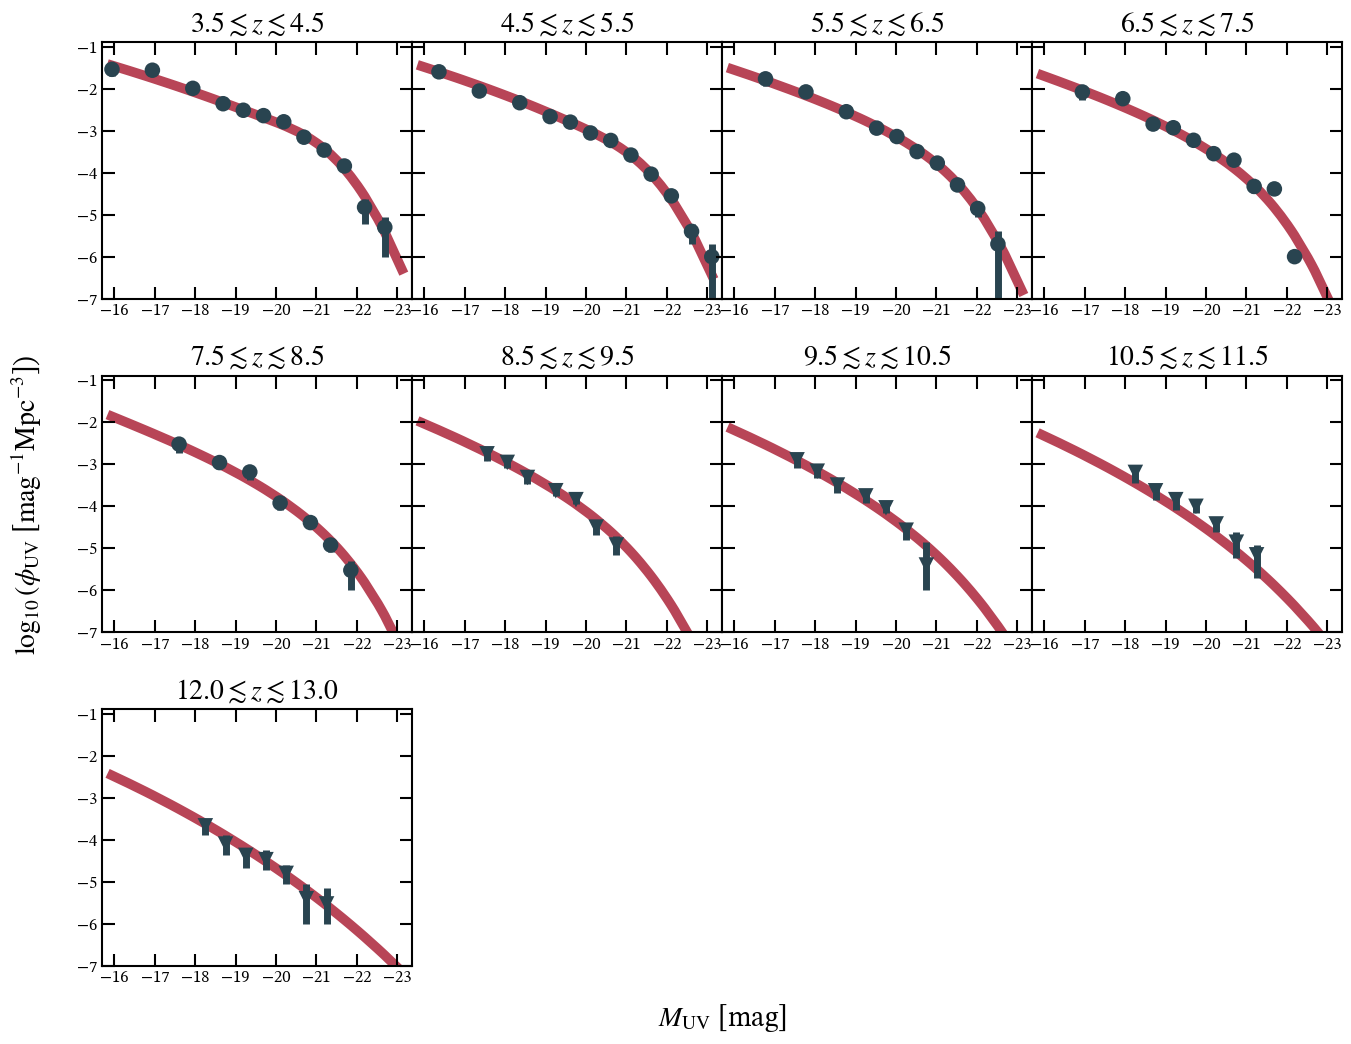

In [387]:
zs = [4, 5, 6, 7, 8, 9, 10, 11, 12.5]
z_errs = [0.5, 0.5, 0.5, 0.5,0.5, 0.5, 0.5, 0.5, 0.5]
evolving_UVLF = evolving_UVLF_fit(my_UVLF, plot_from_chain = False, comparison_fits = [fiducial], #comparison_fits = [fiducial, redshift_dependent, mass_dependent, non_evolving],
                    comparison_labels = ['best fit'], #comparison_labels = ['fiducial', 'redshift dependent', 'mass dependent', 'non evolving'], 
                    ncols = 4, 
                fit_colors = [eplots.red], #fit_colors = [eplots.red, eplots.turquoise, eplots.yellow, eplots.periwinkle], 
                z_plot = zs, z_errs = z_errs, show_chi2 = True)

In [388]:
evolving_UVLF.savefig('/Users/eb35267/Desktop/figures/Qual_26/Mock/fiducial.png', dpi = 300)

In [ ]:
def sfe_shape_diff_z(my_UVLF, param_values, zs = None, Mhtab = None, id_max = False):
    """
    Plot SFE vs. halo mass at different redshifts
    Inputs:
        my_UVLF [eMCMC UVLF object]: UVLF object used for its methods such as applying time evolution to parameter values & wrapping them in the
                                        right format for zeus21
        param_values [1darray]: values of parameters to calculate SFE
        zs [1darray]: redshifts to plot
        Mhtab [1darray]: log10(Mh) to plot over 
        id_max [bool]: Whether or not to identify the maximum SFE at the highest and lowest redshift bin
    Returns:
        fig: A figure showing the SFE over the range of given halo masses & redshifts
    """

    if zs is None:
        zs = np.arange(4, 16, 2)

    if Mhtab is None: 
        Mhtab = np.linspace(9, 13, 200)

    fig = plt.figure(figsize=(6, 4.5))            
    ax_rect  = [0.10, 0.12, 0.78, 0.80]       # left, bottom, width, height (0-1)
    cax_rect = [0.895, 0.12, 0.04, 0.80]      # narrow right slot for cbar
    ax = fig.add_axes(ax_rect)

    if len(zs)>1:
        cmap, sm, boundaries = eplots.create_custom_colorbar([eplots.yellow, eplots.turquoise], zs)
    
    for z in zs:
        # Calculate parameters at this z
        params = my_UVLF.time_evolution(param_values, z)
        Astro_Parameters = my_UVLF.param_wrapper(params)
        # Calculate SFE
        SFEs = my_UVLF.CosmoParams.OmegaM/my_UVLF.CosmoParams.OmegaB * zeus21.sfrd.fstarofz(
            Astro_Parameters, my_UVLF.CosmoParams, z, 10**Mhtab)
        # Assign color
        if len(zs) > 1:
            frac = (z - min(zs)) / (max(zs) - min(zs))
            color = cmap(frac)
        else:
            color = eplots.yellow
        # Plot
        plt.plot(Mhtab, SFEs, color = color, ls = '-', zorder = 0)

        if ((z == max(zs) or z==min(zs)) and id_max): # Putting text on the plot indicating the maximum SFE for the highest & lowest redshifts
            max_idx = np.argmax(SFEs) # Maximum /= M_c unless the power law indices are the same!
            plt.scatter(Mhtab[max_idx], SFEs[max_idx], color = color, s = 100, zorder = 1)
            if z==min(zs): # Positioning the text
                x = (Mhtab[max_idx]-0.8)
                y = SFEs[max_idx]-0.02
            else:
                x = Mhtab[max_idx]
                y = 0.6*SFEs[max_idx]
            plt.text(x, y, fr'$f_\star = {round(SFEs[max_idx], 2)}$', color = color, ha = 'center', 
                         va = 'center', size = 17)

    if len(zs)>1:
    # Color bar things:
        cax = fig.add_axes(cax_rect)
        cbar = fig.colorbar(sm, cax=cax, boundaries=boundaries, ticks=zs, aspect = 14)
        cbar.set_label(r'$z$')

    # Labels
    ax.set_xlabel(r'$\log{M_h/M_{\odot}}$')
    ax.set_ylabel(r'$f_{\star} = \dot M_{\star} / \dot M_{\rm{gas}}$')
    ax.set_yscale('log')
        
        
    return fig, ax

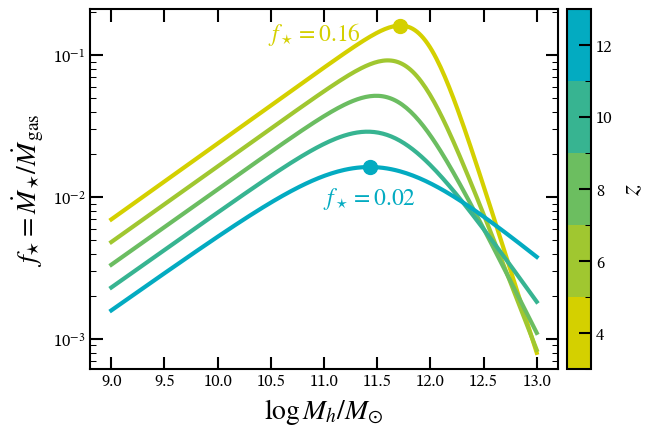

In [12]:
test = sfe_shape_diff_z(my_UVLF, fiducial, id_max = True, zs = [4, 6, 8, 10, 12])

In [921]:
def MUV_to_SFR(my_UVLF, MUV):
    LUV = 10**((51.63-MUV)/2.5)
    SFR = LUV*my_UVLF.Astro_Parameters._kappaUV

    return SFR

def SFR_to_fstar(my_UVLF, SFR, M, z):
    fduty = np.exp(-zeus21.sfrd.Matom(z)/M)
    dMh_dt = zeus21.sfrd.dMh_dt(my_UVLF.Astro_Parameters, my_UVLF.CosmoParams, my_UVLF.HMFintclass, M, z)

    return (my_UVLF.CosmoParams.OmegaM/my_UVLF.CosmoParams.OmegaB) * SFR / (fduty * dMh_dt)

def remove_dust(my_UVLF, MUV, z):
    return MUV - zeus21.UVLFs.AUV(my_UVLF.Astro_Parameters, z, MUV)

def get_fstar(my_UVLF, param_values, M, z):
    Mhtab_og = my_UVLF.HMFintclass.Mhtab # Save this to reset it later. There's probably a more elegant solution I could come up with at another time
    Mhtab = 10**np.array([M])
    my_UVLF.HMFintclass.Mhtab = Mhtab # Set the UVLF table of halo masses to the input value

    MUVcenters_lowres, MUVwidths_lowres = my_UVLF.get_all_MUV_bins() # Get coarse MUV binning
    MUVcenters, MUVwidths = np.linspace(MUVcenters_lowres.min(), MUVcenters_lowres.max(), 1000), np.full(1000, 0.5)
    MUVwidths = np.full_like(MUVcenters, 0.5)

    z_err = 0.5
    weights = my_UVLF.UVLF_wrapper(z,z_err,MUVcenters, MUVwidths, param_values, return_weights = True)

    MUV_dusted = MUVcenters[np.argmax(weights)]
    
    print(MUV_dusted)
    
    MUV_bar = remove_dust(my_UVLF, MUV_dusted, z)

    sig = my_UVLF.time_evolution(redshift_dependent, z)[-1][0]

    MUV_1sig = np.array([MUV_bar+sig, MUV_bar, MUV_bar-sig])

    SFR_1sig = MUV_to_SFR(my_UVLF, MUV_1sig)

    fstar_1sig = SFR_to_fstar(my_UVLF, SFR_1sig, Mhtab, z)

    my_UVLF.HMFintclass.Mhtab = Mhtab_og # Reset the Mhtab

    return fstar_1sig

# Interpret scatter as scatter in SFE

In [130]:
def propagate_error(my_UVLF, param_values, M, z):
    HMFtab_og = my_UVLF.HMFintclass.HMFtab 
    HMFtab = np.array(10**M)
    my_UVLF.HMFintclass.Mhtab = HMFtab
    MUV_bar, sigUV = get_MUV_bar_sigma(my_UVLF, param_values, z)
    
    LUV = get_LUV(MUV_bar)
    sig_LUV = 0.4 * np.log(10) * LUV * sigUV # Don't need to multiply by the zeropoint

    f_b = my_UVLF.CosmoParams.OmegaB/my_UVLF.CosmoParams.OmegaM
    dMh_dt = zeus21.sfrd.dMh_dt(my_UVLF.Astro_Parameters, my_UVLF.CosmoParams, my_UVLF.HMFintclass, HMFtab, z)

    sig_fstar = sig_LUV * my_UVLF.Astro_Parameters._kappaUV / (f_b * dMh_dt)

    my_UVLF.HMFintclass.HMFtab = HMFtab_og

    return sig_fstar

def get_LUV(MUV):
    return 10**((51.63-MUV)/2.5)

def get_MUV_bar_sigma(my_UVLF, param_values, z):
    param_list = my_UVLF.time_evolution(param_values, z)
    AstroParams = my_UVLF.param_wrapper(param_list)
    SFR = zeus21.sfrd.SFR_II(AstroParams,my_UVLF.CosmoParams,my_UVLF.HMFintclass, my_UVLF.HMFintclass.Mhtab, z, z)
        
    MUVbarlist = zeus21.UVLFs.MUV_of_SFR(SFR, AstroParams._kappaUV) #avg for each Mh
    MUVbarlist = np.fmin(MUVbarlist,zeus21.constants._MAGMAX)

    sigmaUV = AstroParams.sigmaUV

    return MUVbarlist, sigmaUV

In [206]:
 def sfe_shape_diff_z(my_UVLF, param_values, zs = None, Mhtab = None, id_max = False):
    """
    Plot SFE vs. halo mass at different redshifts
    Inputs:
        my_UVLF [eMCMC UVLF object]: UVLF object used for its methods such as applying time evolution to parameter values & wrapping them in the
                                        right format for zeus21
        param_values [1darray]: values of parameters to calculate SFE
        zs [1darray]: redshifts to plot
        Mhtab [1darray]: log10(Mh) to plot over 
        id_max [bool]: Whether or not to identify the maximum SFE at the highest and lowest redshift bin
    Returns:
        fig: A figure showing the SFE over the range of given halo masses & redshifts
    """

    if zs is None:
        zs = np.arange(4, 16, 2)

    if Mhtab is None: 
        Mhtab = np.linspace(9, 13, 200)

    fig = plt.figure(figsize=(6, 4.5))            
    ax_rect  = [0.10, 0.12, 0.78, 0.80]       # left, bottom, width, height (0-1)
    cax_rect = [0.895, 0.12, 0.04, 0.80]      # narrow right slot for cbar
    ax = fig.add_axes(ax_rect)

    if len(zs)>1:
        cmap, sm, boundaries = eplots.create_custom_colorbar([eplots.yellow, eplots.turquoise], zs)


    mins = []
    maxs = []
    
    for z in zs:
        # Calculate parameters at this z
        params = my_UVLF.time_evolution(param_values, z)
        Astro_Parameters = my_UVLF.param_wrapper(params)
        # Calculate SFE
        SFEs = my_UVLF.CosmoParams.OmegaM/my_UVLF.CosmoParams.OmegaB * zeus21.sfrd.fstarofz(
            Astro_Parameters, my_UVLF.CosmoParams, z, 10**Mhtab)

        # Calculate delta SFE
        delta_SFEs = propagate_error(my_UVLF, param_values, Mhtab, z)

        # Assign color
        if len(zs) > 1:
            frac = (z - min(zs)) / (max(zs) - min(zs))
            color = cmap(frac)
        else:
            color = eplots.yellow
        # Plot
        plt.plot(Mhtab, SFEs, color = color, ls = '-')
        low_bound, high_bound = np.fmax(SFEs-delta_SFEs, 0), np.fmin(SFEs+delta_SFEs, 1)
        ax.fill_between(Mhtab, low_bound, high_bound, color = color, alpha = 0.2)
        plt.plot(Mhtab, low_bound, color = color, ls = 'dotted', lw = 1)
        plt.plot(Mhtab, high_bound, color = color, ls = 'dotted', lw = 1)
        mins.append(min(SFEs))
        maxs.append(max(high_bound))

        if ((z == max(zs) or z==min(zs)) and id_max): # Putting text on the plot indicating the maximum SFE for the highest & lowest redshifts
            max_idx = np.argmax(SFEs) # Maximum /= M_c unless the power law indices are the same!
            plt.scatter(Mhtab[max_idx], SFEs[max_idx], color = color, s = 100, zorder = 1)
            if z==min(zs): # Positioning the text
                x = (Mhtab[max_idx]-0.8)
                y = SFEs[max_idx]-0.02
            else:
                x = Mhtab[max_idx]
                y = 0.6*SFEs[max_idx]
            plt.text(x, y, fr'$f_\star = {round(SFEs[max_idx], 2)}$', color = color, ha = 'center', 
                         va = 'center', size = 17)

    if len(zs)>1:
    # Color bar things:
        cax = fig.add_axes(cax_rect)
        cbar = fig.colorbar(sm, cax=cax, boundaries=boundaries, ticks=zs, aspect = 14)
        cbar.set_label(r'$z$')

    # Labels
    ax.set_xlabel(r'$\log{M_h/M_{\odot}}$')
    ax.set_ylabel(r'$f_{\star} = \dot M_{\star} / \dot M_{\rm{gas}}$')
    ax.set_yscale('log')
    ax.set_ylim(min(mins), 1.1*max(maxs))
        
        
    return fig, ax

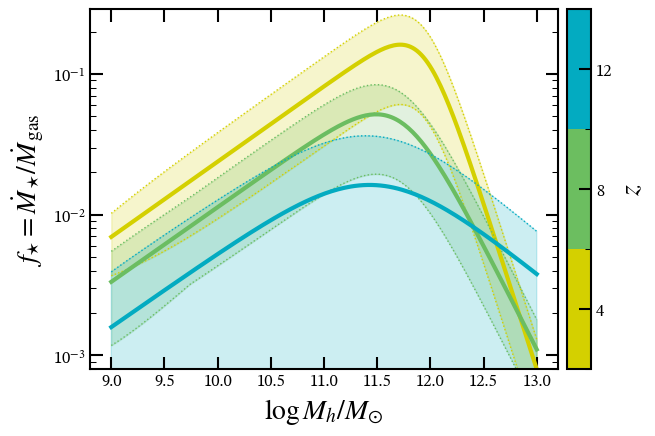

In [215]:
test = sfe_shape_diff_z(my_UVLF, fiducial, zs = np.arange(4, 14, 4))

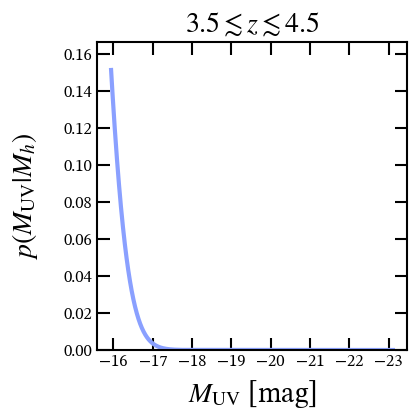

In [940]:
PMUV = eplots.PMUV(my_UVLF, redshift_dependent, zs = [z], Mhtab = np.array([10]))

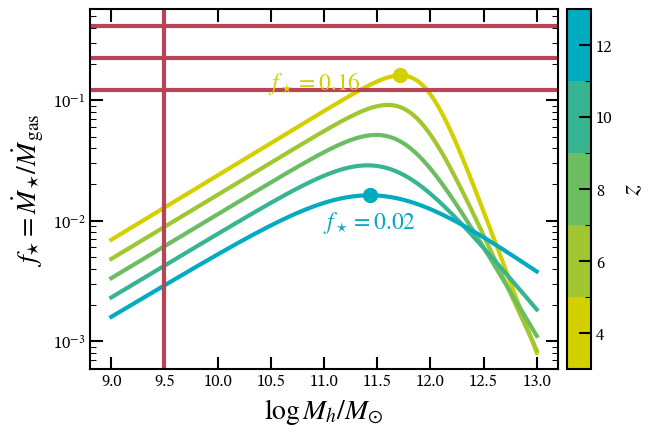

In [909]:
sfe_fig, ax= sfe_shape_diff_z(my_UVLF, fiducial, id_max = True, zs = np.arange(4, 12.5, 2))
ax.axvline(M)
ax.axhline(fstar_1sig[0])
ax.axhline(fstar_1sig[1])
ax.axhline(fstar_1sig[2])

In [885]:
fstar_1sig

array([0.08370457, 0.15486354, 0.28651619])

# Try going forward

In [833]:
params = my_UVLF.time_evolution(redshift_dependent, zcenter = z)
Astro_Params = my_UVLF.param_wrapper(params)

In [834]:
SFRlist = zeus21.sfrd.SFR_II(Astro_Params, my_UVLF.CosmoParams, my_UVLF.HMFintclass, np.array([10**M]), z, z)
print(SFRlist)

[12.44909549]


In [862]:
MUVbarlist = zeus21.UVLFs.MUV_of_SFR(SFRlist, my_UVLF.Astro_Parameters._kappaUV)
print(MUVbarlist)

[-20.95609989]


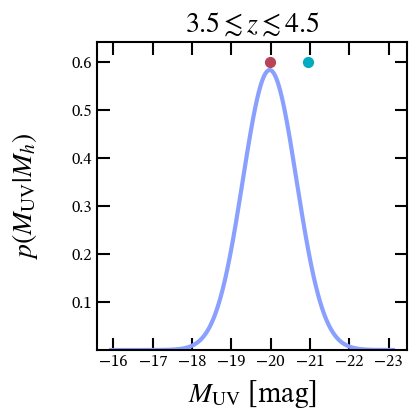

In [867]:
test = eplots.PMUV(my_UVLF, redshift_dependent, Mhtab = np.array([M]), zs = [z])
test[0].axes[0].scatter(-19.973573573573574, 0.6, s= 50, color = eplots.red)
test[0].axes[0].scatter(MUVbarlist, 0.6, s= 50, color = eplots.turquoise)

In [744]:
test[0].axes[0]

<Axes: title={'center': '$3.5 \\lesssim z \\lesssim 4.5$'}>

In [941]:
51.63/2.5

20.652

Text(0, 0.5, '$d\\sigma_{\\rm{UV}}/dz$')

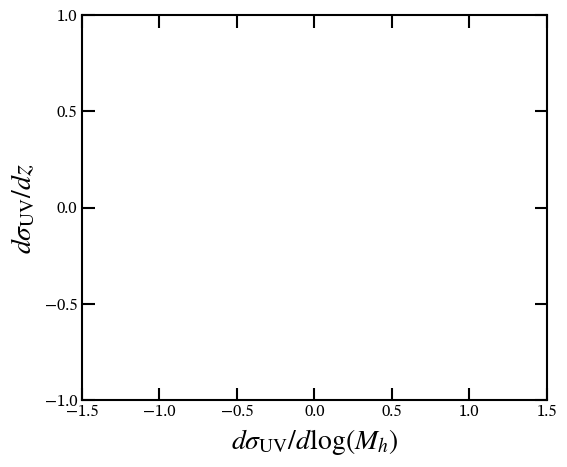

In [385]:
fig, ax = plt.subplots()
fig.set_size_inches(6, 5)

ax.set_ylim(-1, 1)
ax.set_xlim(-1.5, 1.5)
ax.set_xlabel(r'$d\sigma_{\rm{UV}}/d\log(M_{h})$')
ax.set_ylabel(r'$d\sigma_{\rm{UV}}/dz$')

In [386]:
fig.savefig('/Users/eb35267/Desktop/figures/Qual_26/Mock/step_1.png')

In [2]:
age_of_universe(10)

0.46588723808016774

In [5]:
age_of_universe(25)

0.12824103690598562